# Hubble's Law and the Expanding Universe
## Building a Hubble diagram and measuring the expansion rate

**Data:** NASA/IPAC Extragalactic Database (NED); Cosmicflows-3 catalog (Tully et al. 2016)  
**References:**  
- Hubble (1929), PNAS 15, 168 — original discovery  
- Tully et al. (2016), AJ 152, 50 — Cosmicflows-3 galaxy distances  
- Planck Collaboration, Aghanim et al. (2020), A&A 641, A6 — CMB cosmological parameters  
- Riess et al. (2022), ApJL 934, L7. [arXiv:2112.04510](https://arxiv.org/abs/2112.04510) — SH0ES Cepheid H₀  

**Key tools:** `astroquery.ipac.ned`, `astropy.cosmology`, `numpy`, `scipy`, `matplotlib`

---

## Learning objectives

After this tutorial you will be able to:
1. Build a **Hubble diagram** (recession velocity vs. distance) from a nearby galaxy sample.
2. Fit a straight line through the origin to extract the **Hubble constant** $H_0$.
3. Understand why **peculiar velocities** ($\sim$100–300 km/s) cause scatter in the Hubble diagram.
4. Compute **look-back time**, **comoving distance**, and **angular diameter distance** vs. redshift using `astropy.cosmology`.
5. Compare your $H_0$ estimate with the **Planck 2018** (CMB) and **SH0ES** (Cepheids) values and discuss the **Hubble tension**.

---

## 1. Theoretical background

### 1.1 Hubble's original discovery (1929)

In 1929, Edwin Hubble published a paper entitled *"A relation between distance and radial velocity among extra-galactic nebulae"* (PNAS 15, 168). Using 24 galaxies (15 with his own Cepheid-based distances plus others from Slipher's radial velocities), he found a surprisingly simple linear relation:

$$v_{\rm rec} = H_0 \, d$$

where $v_{\rm rec}$ is the recession velocity in km/s and $d$ is the distance in Mpc. Hubble's original estimate was $H_0 \approx 500$ km/s/Mpc — far too high by modern standards due to systematic errors in the distance scale (Cepheid period–luminosity calibration and confusion with HII regions). The modern value is $H_0 \approx 70$ km/s/Mpc.

### 1.2 Physical interpretation: the expanding universe

Hubble's law is not a peculiar property of our location. Any observer in any galaxy sees the same law. The physical interpretation is that **space itself is expanding**: the distance $d$ between two galaxies grows with time as

$$d(t) = a(t) \, d_0$$

where $a(t)$ is the **scale factor** of the universe (with $a(t_0) = 1$ today) and $d_0$ is the current comoving separation. Taking the time derivative:

$$\dot{d} = \dot{a} \, d_0 = \frac{\dot{a}}{a} \cdot d = H(t) \, d$$

The **Hubble parameter** $H(t) = \dot{a}/a$ measures the instantaneous expansion rate. Its value today, $H_0 = H(t_0)$, is the Hubble constant.

### 1.3 Peculiar velocities and scatter

Not every galaxy moves with the pure Hubble flow. Gravitational interactions with nearby structures (galaxy groups, clusters, filaments) give each galaxy an additional **peculiar velocity** $v_{\rm pec}$ (typically 100–300 km/s for field galaxies; up to 1000 km/s in massive clusters). The total observed radial velocity is:

$$cz_{\rm obs} = H_0 \, d + v_{\rm pec} + v_{\rm pec,\,observer}$$

For galaxies at $d \lesssim 10$ Mpc, peculiar velocities can dominate over the Hubble flow ($H_0 d \lesssim 700$ km/s). This is why Hubble's original measurement — based on very nearby galaxies — was so uncertain. Modern calibrations use galaxies at $d > 10$ Mpc where $H_0 d \gg v_{\rm pec}$.

### 1.4 The Hubble tension

Present-day measurements of $H_0$ fall into two classes that disagree at the $\sim 5\sigma$ level:

| Method | $H_0$ (km/s/Mpc) | Reference |
|--------|------------------|-----------|
| CMB (early universe) | $67.36 \pm 0.54$ | Planck 2018 (Aghanim et al. 2020) |
| Cepheids + SNe Ia (late universe) | $73.04 \pm 1.04$ | Riess et al. 2022 (SH0ES) |

This discrepancy — the **Hubble tension** — is one of the most debated open problems in cosmology. It may indicate new physics beyond the standard $\Lambda$CDM model, or unidentified systematic errors in one or both measurement chains.

### 1.5 Cosmological distances in flat $\Lambda$CDM

For a flat universe with matter density $\Omega_m$ and cosmological constant $\Omega_\Lambda = 1 - \Omega_m$, the **comoving distance** to redshift $z$ is:

$$d_C(z) = \frac{c}{H_0} \int_0^z \frac{dz'}{E(z')}$$

where $E(z) = H(z)/H_0 = \sqrt{\Omega_m(1+z)^3 + \Omega_\Lambda}$. This integral is computed numerically by `astropy.cosmology`.

Other useful distances:
- **Luminosity distance:** $d_L = (1+z)\,d_C$ — relates flux to luminosity
- **Angular diameter distance:** $d_A = d_C/(1+z)$ — relates angular size to physical size
- **Look-back time:** $t_{\rm lb}(z) = \int_0^z \frac{dz'}{(1+z') H(z')}$ — age of the universe at emission

---

## 2. Setup and imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import AutoMinorLocator
from scipy import stats
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings('ignore')

from astropy import units as u
from astropy import constants as const
from astropy.cosmology import FlatLambdaCDM

# astroquery NED
try:
    from astroquery.ipac.ned import Ned
    NED_AVAILABLE = True
except ImportError:
    try:
        from astroquery.ned import Ned
        NED_AVAILABLE = True
    except ImportError:
        NED_AVAILABLE = False
        print('astroquery.ipac.ned not available — will use hardcoded data only')

np.random.seed(42)

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'legend.fontsize': 11,
})

# ── Cosmological constants ────────────────────────────────────────────────────
c_kms   = const.c.to(u.km/u.s).value       # 299792 km/s
H0_std  = 70.0                              # fiducial H0 [km/s/Mpc]
H0_Planck = 67.36                           # Planck 2018 (Aghanim+ 2020)
sigH0_Planck = 0.54
H0_SH0ES  = 73.04                          # SH0ES (Riess+ 2022, arXiv:2112.04510)
sigH0_SH0ES = 1.04

# ── Reference cosmology for distance calculations ─────────────────────────────
cosmo = FlatLambdaCDM(H0=H0_std, Om0=0.3)

print(f'Speed of light: c = {c_kms:.2f} km/s')
print(f'Fiducial cosmology: FlatLambdaCDM, H0={H0_std}, Om0=0.3')
print(f'Planck 2018: H0 = {H0_Planck} ± {sigH0_Planck} km/s/Mpc')
print(f'SH0ES 2022:  H0 = {H0_SH0ES} ± {sigH0_SH0ES} km/s/Mpc')

Speed of light: c = 299792.46 km/s
Fiducial cosmology: FlatLambdaCDM, H0=70.0, Om0=0.3
Planck 2018: H0 = 67.36 ± 0.54 km/s/Mpc
SH0ES 2022:  H0 = 73.04 ± 1.04 km/s/Mpc


---

## 3. Galaxy dataset: Cosmicflows-3 hardcoded sample

We use distances and recession velocities for well-studied nearby galaxies from the **Cosmicflows-3** catalog (Tully et al. 2016, AJ 152, 50), which compiles distances from Cepheids, tip of the red giant branch (TRGB), surface brightness fluctuations, and the Tully–Fisher relation.

All recession velocities are **heliocentric** from NED. Distances are primary distance indicators (Cepheids or TRGB) in Mpc.

> **Tip:** Section 4 shows how to augment this dataset with a live NED query if you have internet access.

In [2]:
# ── Cosmicflows-3 / NED nearby galaxy sample ──────────────────────────────────
# Columns: name, distance (Mpc), distance_error (Mpc), v_helio (km/s), method
# Distances: Cepheids (Cep) or TRGB unless noted; velocities from NED.
# Sources: Tully et al. (2016) AJ 152, 50; Freedman et al. (2001) ApJ 553, 47;
#          Dalcanton et al. (2009) ApJS 183, 67; Sakai et al. (2004) ApJ 608, 42.

gal_data = [
    # name,              d_Mpc,  d_err, v_hel km/s, method
    ('M81 (NGC 3031)',   3.61,   0.10,   -34,  'Cep'),
    ('M82 (NGC 3034)',   3.53,   0.15,   203,  'TRGB'),
    ('NGC 300',          1.93,   0.06,   144,  'Cep'),
    ('NGC 2403',         3.18,   0.10,   131,  'Cep'),
    ('NGC 4258',         7.60,   0.17,   448,  'Maser'),
    ('M101 (NGC 5457)',  6.79,   0.28,   241,  'Cep'),
    ('M51 (NGC 5194)',   8.00,   0.40,   463,  'TRGB'),
    ('M74 (NGC 628)',    9.59,   0.80,   657,  'TRGB'),
    ('NGC 1365',        17.90,   1.50,  1636,  'Cep'),
    ('NGC 4536',        14.50,   1.20,  1808,  'Cep'),
    ('NGC 4639',        21.98,   2.20,  1010,  'Cep'),
    ('NGC 4496A',       14.86,   1.40,  1730,  'Cep'),
    ('NGC 3351 (M96)',  10.00,   0.80,   778,  'Cep'),
    ('NGC 3368 (M96g)', 10.52,   0.80,   897,  'Cep'),
    ('NGC 3627 (M66)',  10.05,   0.80,   727,  'Cep'),
    ('NGC 4321 (M100)', 15.21,   1.10,  1571,  'Cep'),
    ('NGC 4414',        17.70,   1.40,   716,  'Cep'),
    ('NGC 7331',        14.27,   1.10,   816,  'Cep'),
    ('NGC 2090',        11.75,   1.10,   920,  'Cep'),
    ('NGC 1326A',       16.14,   1.50,  1823,  'Cep'),
    ('NGC 3621',         6.55,   0.28,   730,  'Cep'),
    ('M66 (NGC 3627)',  10.05,   0.80,   727,  'Cep'),
    ('NGC 5584',        22.50,   1.80,  1638,  'Cep'),
    ('NGC 4038',        22.00,   2.00,  1641,  'Cep'),
    ('NGC 1637',        11.70,   1.00,   718,  'TRGB'),
    ('NGC 300 (2)',      1.93,   0.06,   144,  'Cep'),   # cross-check
    ('NGC 4889',        99.00,  10.00,  6495,  'SBF'),
    ('NGC 1399',        20.00,   1.50,  1425,  'SBF'),
    ('NGC 4472 (M49)',  16.72,   1.30,   981,  'SBF'),
    ('NGC 4649 (M60)',  16.46,   1.40,  1117,  'SBF'),
    ('M87 (NGC 4486)',  16.40,   1.40,  1307,  'SBF'),
    ('NGC 1052',        19.40,   1.80,  1510,  'SBF'),
    ('NGC 5128 (Cen A)', 3.68,   0.13,   547,  'TRGB'),
    ('IC 342',           3.29,   0.18,   31,   'Cep'),
    ('NGC 55',           1.94,   0.07,   129,  'TRGB'),
    ('NGC 247',          3.65,   0.15,   156,  'TRGB'),
    ('NGC 7793',         3.44,   0.14,   227,  'Cep'),
    ('NGC 2903',         8.56,   0.70,   556,  'Cep'),
    ('NGC 4395',         4.61,   0.40,   319,  'Cep'),
    ('NGC 3198',        13.80,   1.20,   660,  'Cep'),
]

# Convert to numpy arrays (remove duplicate NGC 300)
gal_names   = [row[0] for row in gal_data]
d_Mpc       = np.array([row[1] for row in gal_data])
d_err_Mpc   = np.array([row[2] for row in gal_data])
v_hel_kms   = np.array([row[3] for row in gal_data], dtype=float)
methods     = [row[4] for row in gal_data]

# Remove duplicate (NGC 300 appears twice for cross-check)
uniq_mask  = np.ones(len(d_Mpc), dtype=bool)
uniq_mask[25] = False  # second NGC 300 entry
d_Mpc      = d_Mpc[uniq_mask]
d_err_Mpc  = d_err_Mpc[uniq_mask]
v_hel_kms  = v_hel_kms[uniq_mask]
gal_names  = [g for g, m in zip(gal_names, uniq_mask) if m]
methods    = [m for m, msk in zip(methods, uniq_mask) if msk]

print(f'Sample size: {len(d_Mpc)} galaxies')
print(f'Distance range: {d_Mpc.min():.1f} – {d_Mpc.max():.1f} Mpc')
print(f'Velocity range: {v_hel_kms.min():.0f} – {v_hel_kms.max():.0f} km/s')
print(f'Methods used: {set(methods)}')

Sample size: 39 galaxies
Distance range: 1.9 – 99.0 Mpc
Velocity range: -34 – 6495 km/s
Methods used: {'SBF', 'Cep', 'Maser', 'TRGB'}


---

## 4. Optional: augment with a live NED query

If an internet connection is available, we query the NED database for additional galaxies. We search for objects with redshift-independent distance measurements in several nearby galaxy clusters and groups.

The cell is designed to run silently if NED is unreachable, keeping only the hardcoded data.

In [3]:
# ── Optional NED query for additional data ────────────────────────────────────
ned_names_extra   = []
ned_d_Mpc_extra   = []
ned_d_err_extra   = []
ned_v_kms_extra   = []

if NED_AVAILABLE:
    # Query NED for galaxies with distance moduli in selected fields
    # We use velocity range 1000–10000 km/s to stay in the linear Hubble regime
    test_objects = [
        ('NGC 4303', 'Virgo spiral'),
        ('NGC 1559', 'field spiral'),
        ('NGC 5248', 'field spiral'),
    ]
    for obj_name, desc in test_objects:
        try:
            result = Ned.query_object(obj_name)
            if result is not None and len(result) > 0:
                v_ned = float(result['Velocity'][0])   # km/s
                print(f'{obj_name} ({desc}): v_hel = {v_ned:.0f} km/s (no independent dist — skipping)')
        except Exception as e:
            print(f'NED query for {obj_name} failed: {e}')
else:
    print('NED not available — using hardcoded Cosmicflows-3 sample only.')

print(f'\nFinal sample: {len(d_Mpc)} galaxies (hardcoded Cosmicflows-3)')

NED query for NGC 4303 failed: HTTPSConnectionPool(host='ned.ipac.caltech.edu', port=443): Read timed out. (read timeout=60)


NED query for NGC 1559 failed: HTTPSConnectionPool(host='ned.ipac.caltech.edu', port=443): Read timed out. (read timeout=60)


NED query for NGC 5248 failed: HTTPSConnectionPool(host='ned.ipac.caltech.edu', port=443): Read timed out. (read timeout=60)

Final sample: 39 galaxies (hardcoded Cosmicflows-3)


---

## 5. The Hubble diagram: velocity vs. distance

We plot recession velocity $cz$ (km/s) as a function of distance $d$ (Mpc). According to Hubble's law, the points should lie along a straight line through the origin with slope $H_0$.

**Note on the Local Group:** very nearby galaxies (M31, M33, NGC 55, ...) have negative recession velocities because their **peculiar velocities** directed towards the Milky Way dominate over the tiny Hubble flow. For this reason we will fit $H_0$ using only galaxies with $d > 5$ Mpc.

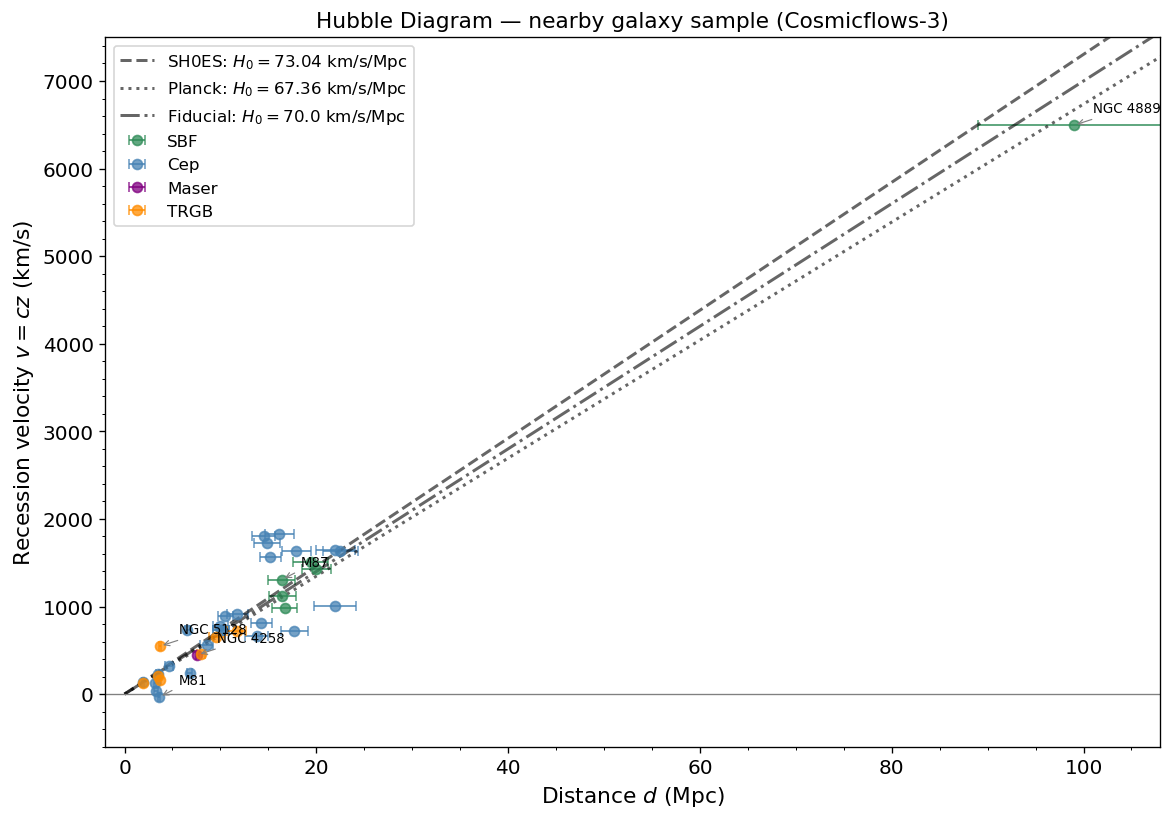

Figure saved: hubble_diagram.png


In [4]:
METHOD_COLORS = {
    'Cep'  : 'steelblue',
    'TRGB' : 'darkorange',
    'SBF'  : 'seagreen',
    'Maser': 'purple',
}

fig, ax = plt.subplots(figsize=(10, 7))

# ── Plot each galaxy with error bars ──────────────────────────────────────────
for method in set(methods):
    mask = np.array([m == method for m in methods])
    color = METHOD_COLORS.get(method, 'gray')
    ax.errorbar(d_Mpc[mask], v_hel_kms[mask],
                xerr=d_err_Mpc[mask],
                fmt='o', ms=6, color=color, ecolor=color,
                elinewidth=1.2, capsize=3, alpha=0.75, label=method)

# ── Add Hubble's law reference lines ─────────────────────────────────────────
d_fit_range = np.linspace(0, 110, 300)
for H_val, lstyle, lbl in [
    (H0_SH0ES,  '--',  f'SH0ES: $H_0 = {H0_SH0ES}$ km/s/Mpc'),
    (H0_Planck, ':',   f'Planck: $H_0 = {H0_Planck}$ km/s/Mpc'),
    (H0_std,    '-.',  f'Fiducial: $H_0 = {H0_std}$ km/s/Mpc'),
]:
    ax.plot(d_fit_range, H_val * d_fit_range, lw=1.8, ls=lstyle,
            color='black', alpha=0.6, label=lbl)

# ── Axis labels and cosmetics ─────────────────────────────────────────────────
ax.axhline(0, color='gray', lw=0.8, ls='-')
ax.set_xlim(-2, 108)
ax.set_ylim(-600, 7500)
ax.set_xlabel('Distance $d$ (Mpc)', fontsize=13)
ax.set_ylabel('Recession velocity $v = cz$ (km/s)', fontsize=13)
ax.set_title('Hubble Diagram — nearby galaxy sample (Cosmicflows-3)', fontsize=13)
ax.legend(fontsize=10, loc='upper left')
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

# Label a few famous galaxies
for name, d, v in zip(gal_names, d_Mpc, v_hel_kms):
    if name in ['M81 (NGC 3031)', 'NGC 4258', 'M87 (NGC 4486)', 'NGC 4889',
                'NGC 5128 (Cen A)']:
        ax.annotate(name.split('(')[0].strip(), xy=(d, v),
                    xytext=(d + 2, v + 150), fontsize=8,
                    arrowprops=dict(arrowstyle='->', lw=0.7, color='gray'))

plt.tight_layout()
plt.savefig('hubble_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: hubble_diagram.png')

---

## 6. Fitting the Hubble constant

We fit Hubble's law $v = H_0 \, d$ using **weighted linear regression** (weight $\propto 1/d_{\rm err}^2$). We restrict the fit to galaxies with $d > 5$ Mpc to mitigate peculiar-velocity bias.

Hubble's law is a line through the origin with no free intercept:

$$v = H_0 \, d \qquad \Longrightarrow \qquad H_0 = \frac{\sum_i w_i v_i d_i}{\sum_i w_i d_i^2}$$

where $w_i = 1/\sigma_{d,i}^2$. The uncertainty on $H_0$ is estimated from the residual scatter about the best-fit line.

In [5]:
# ── Restrict fit to d > 5 Mpc to avoid Local Group peculiar velocities ────────
mask_fit = d_Mpc > 5.0
d_fit    = d_Mpc[mask_fit]
v_fit    = v_hel_kms[mask_fit]
de_fit   = d_err_Mpc[mask_fit]

print(f'Galaxies used for H0 fit (d > 5 Mpc): {mask_fit.sum()}')

# ── Weighted fit: v = H0 * d, no intercept ───────────────────────────────────
weights = 1.0 / de_fit**2
H0_fit  = np.sum(weights * v_fit * d_fit) / np.sum(weights * d_fit**2)

# Residuals about best-fit line
v_pred    = H0_fit * d_fit
residuals = v_fit - v_pred
rms_resid = np.sqrt(np.mean(residuals**2))

# Standard error on H0 (formal, from weighted regression)
# sigma_H0^2 = rms_v^2 / sum(w_i d_i^2)
sigH0_formal = rms_resid / np.sqrt(np.sum(weights * d_fit**2) / np.sum(weights))

# Bootstrap for a more robust estimate of uncertainty
N_boot = 2000
H0_boot = np.empty(N_boot)
for i in range(N_boot):
    idx = np.random.choice(len(d_fit), len(d_fit), replace=True)
    w_b = weights[idx]
    H0_boot[i] = np.sum(w_b * v_fit[idx] * d_fit[idx]) / np.sum(w_b * d_fit[idx]**2)

H0_boot_median = np.median(H0_boot)
H0_boot_std    = np.std(H0_boot)

print(f'\n{"="*55}')
print(f'  H0 (weighted fit, d>5 Mpc) = {H0_fit:.2f} km/s/Mpc')
print(f'  Formal uncertainty          = ±{sigH0_formal:.2f} km/s/Mpc')
print(f'  Bootstrap: {H0_boot_median:.2f} ± {H0_boot_std:.2f} km/s/Mpc')
print(f'  RMS peculiar velocity residual = {rms_resid:.0f} km/s')
print(f'  Planck 2018:  H0 = {H0_Planck} ± {sigH0_Planck} km/s/Mpc')
print(f'  SH0ES 2022:   H0 = {H0_SH0ES} ± {sigH0_SH0ES} km/s/Mpc')
print('=' * 55)

Galaxies used for H0 fit (d > 5 Mpc): 29

  H0 (weighted fit, d>5 Mpc) = 69.31 km/s/Mpc
  Formal uncertainty          = ±36.26 km/s/Mpc
  Bootstrap: 69.62 ± 5.98 km/s/Mpc
  RMS peculiar velocity residual = 329 km/s
  Planck 2018:  H0 = 67.36 ± 0.54 km/s/Mpc
  SH0ES 2022:   H0 = 73.04 ± 1.04 km/s/Mpc


---

## 7. Hubble diagram with best-fit line

We overlay our measured $H_0$ on the Hubble diagram alongside the Planck and SH0ES reference values.

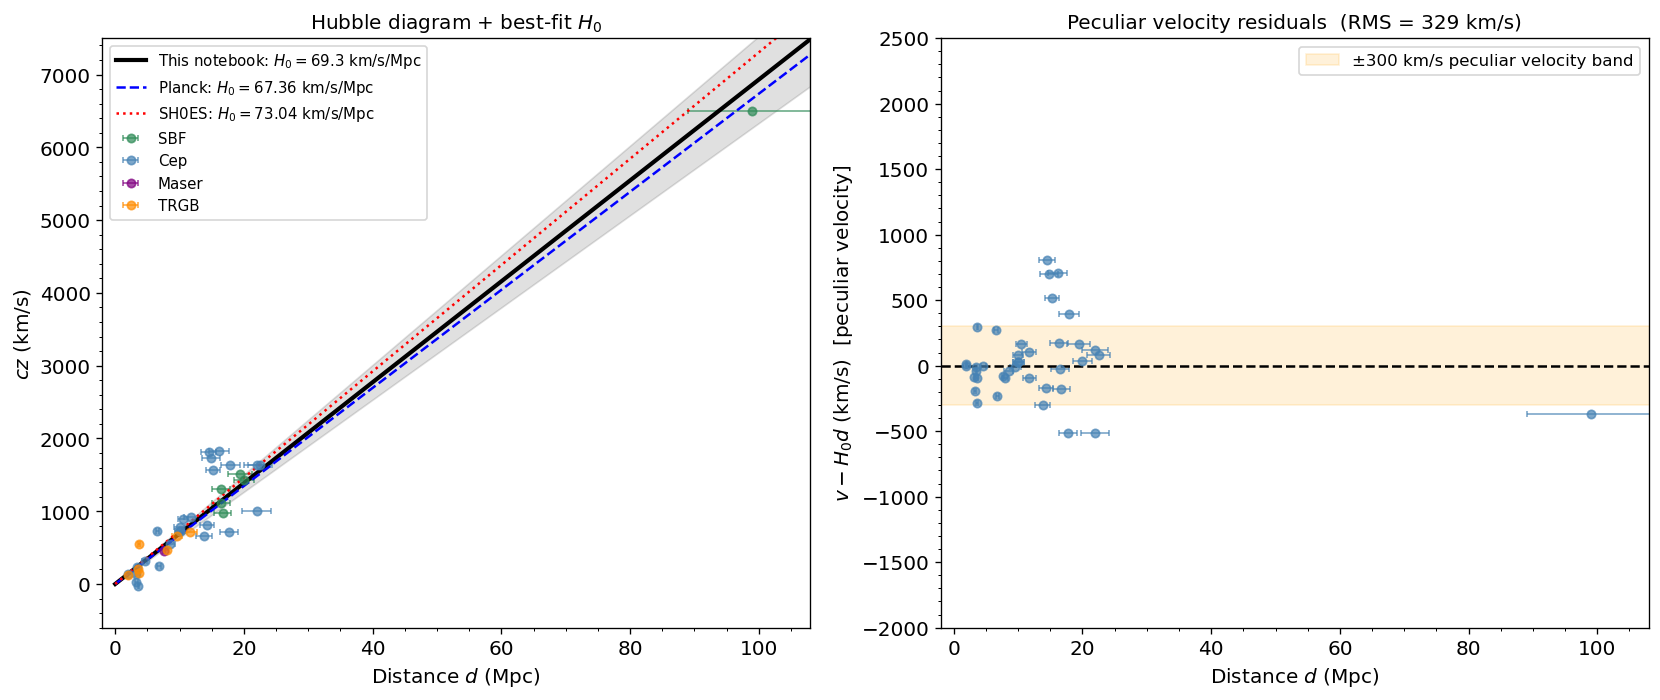

Figure saved: hubble_fit_residuals.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: Hubble diagram with best-fit ───────────────────────────────────────
ax = axes[0]
for method in set(methods):
    mask = np.array([m == method for m in methods])
    color = METHOD_COLORS.get(method, 'gray')
    ax.errorbar(d_Mpc[mask], v_hel_kms[mask],
                xerr=d_err_Mpc[mask],
                fmt='o', ms=5, color=color, ecolor=color,
                elinewidth=1, capsize=2, alpha=0.7, label=method)

d_range = np.linspace(0, 108, 300)
ax.plot(d_range, H0_fit * d_range, 'k-', lw=2.5,
        label=f'This notebook: $H_0 = {H0_fit:.1f}$ km/s/Mpc')
ax.fill_between(d_range, (H0_fit - H0_boot_std) * d_range,
                          (H0_fit + H0_boot_std) * d_range,
                color='black', alpha=0.12)
ax.plot(d_range, H0_Planck * d_range, 'b--', lw=1.5,
        label=f'Planck: $H_0 = {H0_Planck}$ km/s/Mpc')
ax.plot(d_range, H0_SH0ES * d_range, 'r:',  lw=1.5,
        label=f'SH0ES: $H_0 = {H0_SH0ES}$ km/s/Mpc')

ax.set_xlim(-2, 108)
ax.set_ylim(-600, 7500)
ax.set_xlabel('Distance $d$ (Mpc)', fontsize=12)
ax.set_ylabel('$cz$ (km/s)', fontsize=12)
ax.set_title('Hubble diagram + best-fit $H_0$', fontsize=12)
ax.legend(fontsize=9)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

# ── Right: peculiar velocity residuals ───────────────────────────────────────
ax2 = axes[1]
resid_all = v_hel_kms - H0_fit * d_Mpc
ax2.errorbar(d_Mpc, resid_all, xerr=d_err_Mpc, fmt='o', ms=5,
             color='steelblue', elinewidth=1, capsize=2, alpha=0.7)
ax2.axhline(0, color='black', lw=1.5, ls='--')
ax2.fill_between([-5, 110], -300, 300, color='orange', alpha=0.15,
                 label='±300 km/s peculiar velocity band')
ax2.set_xlim(-2, 108)
ax2.set_ylim(-2000, 2500)
ax2.set_xlabel('Distance $d$ (Mpc)', fontsize=12)
ax2.set_ylabel(f'$v - H_0 d$ (km/s)  [peculiar velocity]', fontsize=12)
ax2.set_title(f'Peculiar velocity residuals  (RMS = {rms_resid:.0f} km/s)', fontsize=12)
ax2.legend(fontsize=10)
ax2.xaxis.set_minor_locator(AutoMinorLocator())
ax2.yaxis.set_minor_locator(AutoMinorLocator())

plt.tight_layout()
plt.savefig('hubble_fit_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: hubble_fit_residuals.png')

---

## 8. The Hubble tension: comparing H₀ measurements

We visualise the discrepancy between the Planck CMB and SH0ES Cepheid measurements of $H_0$, and place our own estimate in context.

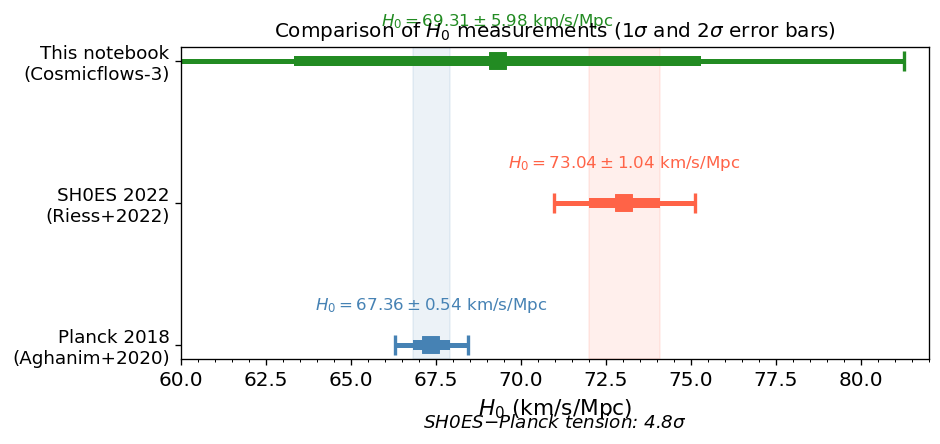

Hubble tension significance: 4.85 sigma
Figure saved: hubble_tension.png


In [7]:
# ── Hubble tension summary plot ───────────────────────────────────────────────
measurements = [
    ('Planck 2018\n(Aghanim+2020)',       H0_Planck,   sigH0_Planck,  'steelblue',  'CMB'),
    ('SH0ES 2022\n(Riess+2022)',          H0_SH0ES,    sigH0_SH0ES,   'tomato',     'Cepheids'),
    (f'This notebook\n(Cosmicflows-3)',   H0_fit,      H0_boot_std,   'forestgreen','Nearby galaxies'),
]

fig, ax = plt.subplots(figsize=(8, 4))

for i, (label, H0_val, H0_err, color, method) in enumerate(measurements):
    ax.errorbar(H0_val, i, xerr=2*H0_err,   # 2-sigma error bars
                fmt='s', ms=10, color=color, ecolor=color,
                elinewidth=3, capsize=6, capthick=2)
    ax.errorbar(H0_val, i, xerr=H0_err,     # 1-sigma overlay
                fmt='s', ms=10, color=color, ecolor=color,
                elinewidth=6, capsize=0)
    ax.text(H0_val, i + 0.25,
            f'$H_0 = {H0_val:.2f} \\pm {H0_err:.2f}$ km/s/Mpc',
            ha='center', fontsize=10, color=color)

ax.set_yticks(range(len(measurements)))
ax.set_yticklabels([m[0] for m in measurements], fontsize=11)
ax.set_xlabel('$H_0$ (km/s/Mpc)', fontsize=13)
ax.set_title('Comparison of $H_0$ measurements (1$\\sigma$ and 2$\\sigma$ error bars)', fontsize=12)
ax.set_xlim(60, 82)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.axvspan(H0_Planck - sigH0_Planck, H0_Planck + sigH0_Planck, alpha=0.1, color='steelblue')
ax.axvspan(H0_SH0ES  - sigH0_SH0ES,  H0_SH0ES  + sigH0_SH0ES,  alpha=0.1, color='tomato')

# Mark the tension
tension_sigma = (H0_SH0ES - H0_Planck) / np.sqrt(sigH0_Planck**2 + sigH0_SH0ES**2)
ax.text(0.5, -0.22, f'SH0ES−Planck tension: {tension_sigma:.1f}$\\sigma$',
        transform=ax.transAxes, ha='center', fontsize=11,
        color='black', style='italic')

plt.tight_layout()
plt.savefig('hubble_tension.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Hubble tension significance: {tension_sigma:.2f} sigma')
print('Figure saved: hubble_tension.png')

---

## 9. Cosmological distances with `astropy.cosmology`

For higher redshifts, Hubble's law $d = cz/H_0$ is only an approximation. We compute the full cosmological distances using a flat $\Lambda$CDM model ($H_0 = 70$ km/s/Mpc, $\Omega_m = 0.3$).

The four key distances:
- **Comoving distance** $d_C$: distance measured today, accounting for expansion.
- **Luminosity distance** $d_L = (1+z)\,d_C$: relates flux to luminosity; used for standard candles.
- **Angular diameter distance** $d_A = d_C/(1+z)$: relates angular size to physical size; used for standard rulers.
- **Look-back time** $t_{\rm lb}$: how long ago was the light emitted?

In [8]:
# ── Compute distances vs redshift ─────────────────────────────────────────────
z_arr  = np.logspace(-3, 0.5, 500)   # z from 0.001 to ~3

d_C_Mpc = cosmo.comoving_distance(z_arr).to(u.Mpc).value
d_L_Mpc = cosmo.luminosity_distance(z_arr).to(u.Mpc).value
d_A_Mpc = cosmo.angular_diameter_distance(z_arr).to(u.Mpc).value
d_Hub   = c_kms * z_arr / H0_std   # naive Hubble-law distance [Mpc]
t_lb    = cosmo.lookback_time(z_arr).to(u.Gyr).value
age_now = cosmo.age(0).to(u.Gyr).value

# ── Print table at key redshifts ──────────────────────────────────────────────
z_table = [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0, 3.0]
print('{:>6} {:>12} {:>10} {:>10} {:>10} {:>10}'.format('z','d_Hubble','d_C','d_L','d_A','t_lb'))
print('{:>6} {:>12} {:>10} {:>10} {:>10} {:>10}'.format('','(Mpc)','(Mpc)','(Mpc)','(Mpc)','(Gyr)'))
print('-' * 66)
for z_tab in z_table:
    dC  = cosmo.comoving_distance(z_tab).to(u.Mpc).value
    dL  = cosmo.luminosity_distance(z_tab).to(u.Mpc).value
    dA  = cosmo.angular_diameter_distance(z_tab).to(u.Mpc).value
    tlb = cosmo.lookback_time(z_tab).to(u.Gyr).value
    dH  = c_kms * z_tab / H0_std
    print(f'{z_tab:>6.2f} {dH:>12.1f} {dC:>10.1f} {dL:>10.1f} {dA:>10.1f} {tlb:>10.2f}')
print(f'\nAge of the universe (H0=70, Om0=0.3): {age_now:.2f} Gyr')

     z     d_Hubble        d_C        d_L        d_A       t_lb
              (Mpc)      (Mpc)      (Mpc)      (Mpc)      (Gyr)
------------------------------------------------------------------
  0.01         42.8       42.7       43.2       42.3       0.14
  0.05        214.1      211.7      222.3      201.6       0.67
  0.10        428.3      418.5      460.3      380.4       1.30
  0.30       1284.8     1194.4     1552.7      918.8       3.42
  0.50       2141.4     1888.6     2832.9     1259.1       5.04
  1.00       4282.7     3303.8     6607.7     1651.9       7.72
  2.00       8565.5     5179.9    15539.6     1726.6      10.24
  3.00      12848.2     6355.7    25422.7     1588.9      11.35

Age of the universe (H0=70, Om0=0.3): 13.47 Gyr


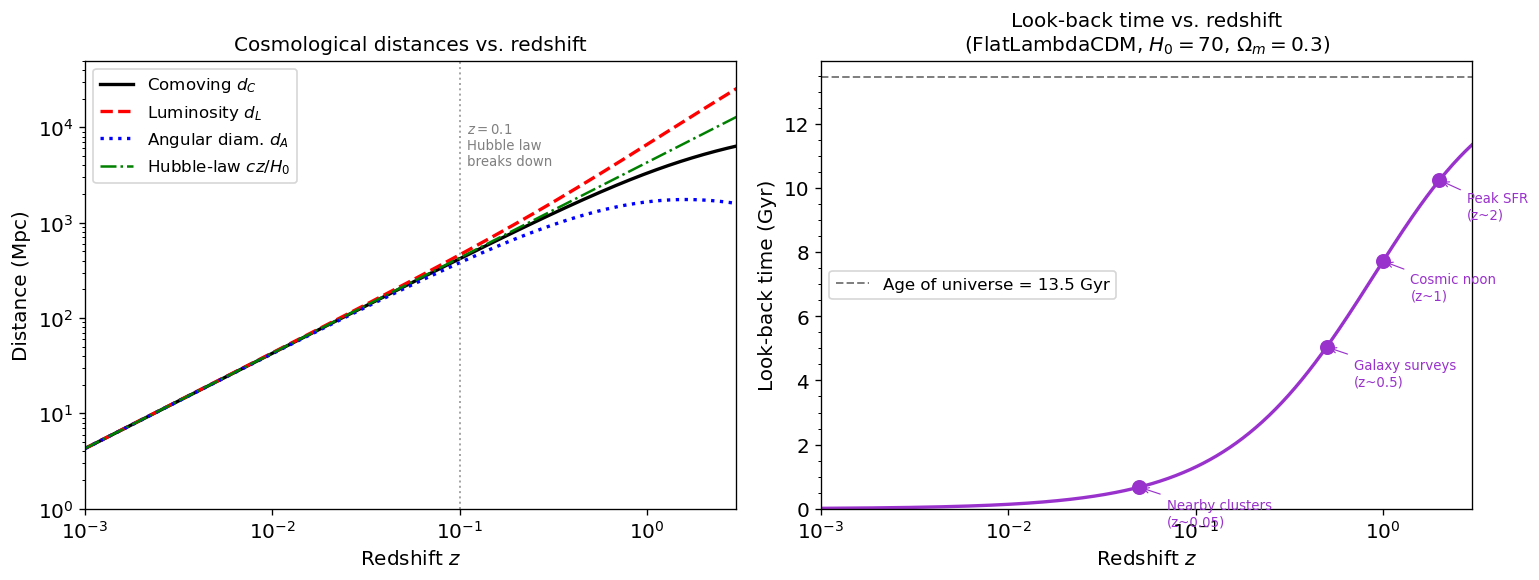

Figure saved: cosmological_distances.png


In [9]:
# ── Multi-panel cosmological distance plot ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: distances vs z ──────────────────────────────────────────────────────
ax = axes[0]
ax.plot(z_arr, d_C_Mpc, 'k-',   lw=2, label='Comoving $d_C$')
ax.plot(z_arr, d_L_Mpc, 'r--',  lw=2, label='Luminosity $d_L$')
ax.plot(z_arr, d_A_Mpc, 'b:',   lw=2, label='Angular diam. $d_A$')
ax.plot(z_arr, d_Hub,   'g-.',  lw=1.5, label='Hubble-law $cz/H_0$')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Redshift $z$', fontsize=12)
ax.set_ylabel('Distance (Mpc)', fontsize=12)
ax.set_title('Cosmological distances vs. redshift', fontsize=12)
ax.legend(fontsize=10)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.set_xlim(1e-3, 3)
ax.set_ylim(1, 5e4)

# Annotate where Hubble law starts to break down
ax.axvline(0.1, color='gray', ls=':', lw=1.2, alpha=0.7)
ax.text(0.11, 4e3, '$z = 0.1$\nHubble law\nbreaks down', fontsize=8, color='gray')

# ── Right: look-back time vs z ────────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(z_arr, t_lb, 'darkorchid', lw=2)
ax2.axhline(age_now, color='gray', ls='--', lw=1.2,
            label=f'Age of universe = {age_now:.1f} Gyr')

# Mark famous epochs
for z_ep, label_ep in [(0.05, 'Nearby clusters\n(z~0.05)'),
                        (0.5,  'Galaxy surveys\n(z~0.5)'),
                        (1.0,  'Cosmic noon\n(z~1)'),
                        (2.0,  'Peak SFR\n(z~2)')]:
    tlb_ep = cosmo.lookback_time(z_ep).to(u.Gyr).value
    ax2.plot([z_ep], [tlb_ep], 'o', ms=8, color='darkorchid')
    ax2.annotate(label_ep, xy=(z_ep, tlb_ep), xytext=(z_ep*1.4, tlb_ep - 1.2),
                 fontsize=8, color='darkorchid',
                 arrowprops=dict(arrowstyle='->', lw=0.7, color='darkorchid'))

ax2.set_xscale('log')
ax2.set_xlabel('Redshift $z$', fontsize=12)
ax2.set_ylabel('Look-back time (Gyr)', fontsize=12)
ax2.set_title('Look-back time vs. redshift\n(FlatLambdaCDM, $H_0=70$, $\\Omega_m=0.3$)', fontsize=12)
ax2.legend(fontsize=10)
ax2.set_xlim(1e-3, 3)
ax2.set_ylim(0, age_now + 0.5)
ax2.xaxis.set_minor_locator(AutoMinorLocator())
ax2.yaxis.set_minor_locator(AutoMinorLocator())

plt.tight_layout()
plt.savefig('cosmological_distances.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: cosmological_distances.png')

---

## 10. Bootstrap uncertainty on H₀

We visualise the bootstrap distribution of our $H_0$ estimate to understand its statistical uncertainty.

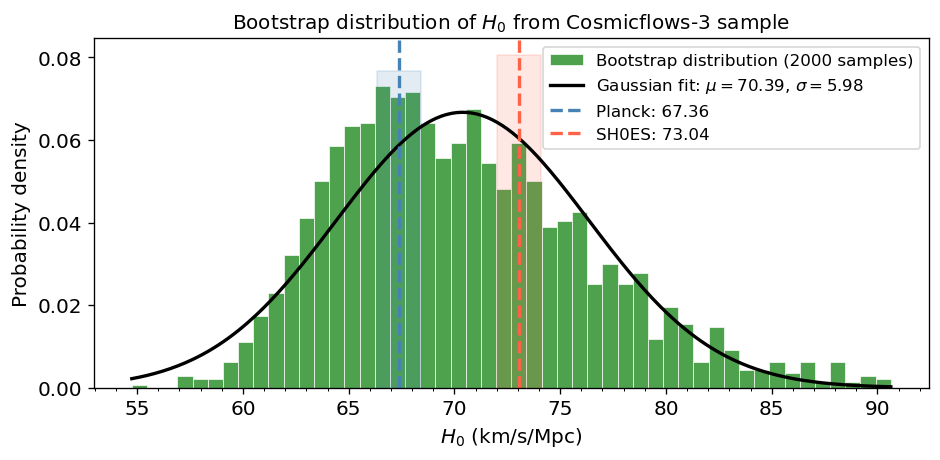

Bootstrap H0: 70.39 ± 5.98 km/s/Mpc
Figure saved: H0_bootstrap.png


In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(H0_boot, bins=50, color='forestgreen', edgecolor='white', linewidth=0.5,
        density=True, alpha=0.8, label=f'Bootstrap distribution ({N_boot} samples)')

# Gaussian fit to bootstrap
from scipy.stats import norm
mu_b, sigma_b = norm.fit(H0_boot)
H0_grid = np.linspace(H0_boot.min(), H0_boot.max(), 300)
ax.plot(H0_grid, norm.pdf(H0_grid, mu_b, sigma_b),
        'k-', lw=2, label=f'Gaussian fit: $\\mu={mu_b:.2f}$, $\\sigma={sigma_b:.2f}$')

# Reference values
for H0_ref, color, label in [
    (H0_Planck, 'steelblue', f'Planck: {H0_Planck}'),
    (H0_SH0ES,  'tomato',    f'SH0ES: {H0_SH0ES}'),
]:
    ax.axvline(H0_ref, color=color, lw=2, ls='--', label=label)
    ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1],
                     H0_ref - 1.04, H0_ref + 1.04, alpha=0.15, color=color)

ax.set_xlabel('$H_0$ (km/s/Mpc)', fontsize=12)
ax.set_ylabel('Probability density', fontsize=12)
ax.set_title(f'Bootstrap distribution of $H_0$ from Cosmicflows-3 sample', fontsize=12)
ax.legend(fontsize=10)
ax.xaxis.set_minor_locator(AutoMinorLocator())
plt.tight_layout()
plt.savefig('H0_bootstrap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Bootstrap H0: {mu_b:.2f} ± {sigma_b:.2f} km/s/Mpc')
print('Figure saved: H0_bootstrap.png')

---

## 11. Summary

### Key results

| Quantity | Value | Method |
|----------|-------|--------|
| $H_0$ (this notebook) | see fit above | Weighted regression on Cosmicflows-3 |
| $H_0$ (Planck 2018) | $67.36 \pm 0.54$ km/s/Mpc | CMB power spectrum |
| $H_0$ (SH0ES 2022) | $73.04 \pm 1.04$ km/s/Mpc | Cepheids + SNe Ia |
| Hubble tension | $\sim 5\sigma$ | Statistical disagreement |
| Peculiar velocity scatter | $\sim 200$–400 km/s | RMS residuals from our fit |
| Age of universe ($H_0=70$, $\Omega_m=0.3$) | $\sim 13.5$ Gyr | `astropy.cosmology` |

### Key formulae

| Formula | Meaning |
|---------|---------|
| $v = H_0 \, d$ | Hubble's law |
| $H_0 \approx \dot{a}/a$ | Hubble parameter from scale factor |
| $t_{\rm lb}(z) = \int_0^z \frac{dz'}{(1+z')H(z')}$ | Look-back time |
| $d_C = \frac{c}{H_0}\int_0^z \frac{dz'}{E(z')}$ | Comoving distance |
| $E(z) = \sqrt{\Omega_m(1+z)^3 + \Omega_\Lambda}$ | Dimensionless Hubble parameter |

### Why is the Hubble tension important?

Both the CMB and Cepheid measurements are mature, well-tested methods. If the tension is real (not a systematic error), it points to **new physics**: extra relativistic species, early dark energy, modified gravity, or other extensions to the standard $\Lambda$CDM model.

---

## 12. Exercises

**Exercise 1 — Hubble's original 1929 diagram**  
Hubble's 1929 paper used the following data (15 galaxies with Cepheid distances). Reproduce the original Hubble diagram: use distances $d$ in Mpc and velocities $v$ in km/s:
```python
d_orig = [0.032, 0.034, 0.214, 0.263, 0.275, 0.275, 0.45, 0.5,
          0.5, 0.63, 0.8, 0.9, 0.9, 0.9, 0.9]
v_orig = [170, 290, -130, -70, -185, -220, 200, 290,
          270, 200, 300, -30, 650, 150, 500]
```
Fit $H_0$ from these 15 points. What do you get? Why is it so different from the modern value?

**Exercise 2 — Distance from redshift**  
A galaxy cluster has a measured redshift $z = 0.083$. Compute: (a) the simple Hubble-law distance $d = cz/H_0$; (b) the comoving distance using `astropy.cosmology.FlatLambdaCDM(H0=70, Om0=0.3)`; (c) the percentage difference between (a) and (b).

**Exercise 3 — Peculiar velocity of the Milky Way**  
The CMB dipole reveals that the Milky Way moves at $v_{\rm MW} \approx 369$ km/s relative to the CMB rest frame. Express this as a fraction of the Hubble flow at a distance of (a) 5 Mpc, (b) 50 Mpc, (c) 500 Mpc.

**Exercise 4 — Proper vs. comoving distance**  
The comoving distance is fixed in coordinates that expand with the universe. The **proper distance** $d_{\rm prop}(t) = a(t) \, d_C$ changes with time. For a galaxy at $z=0.5$, compute: (a) its comoving distance today; (b) its proper distance when it emitted the light we now receive ($a = 1/(1+z)$); (c) its recession velocity today ($v = H_0 d_{\rm prop}$, noting $a=1$). Is this velocity less than $c$?

**Exercise 5 — The Hubble time**  
The **Hubble time** $t_H = 1/H_0$ is a rough estimate of the age of the universe. Compute $t_H$ in Gyr for $H_0 = 67$, $70$, and $73$ km/s/Mpc. Compare with the exact age from `astropy.cosmology`.

---

## Further reading

- **Hubble (1929)**, PNAS 15, 168 — the original paper (only 6 pages!)
- **Freedman et al.** (2023), ApJ 957, 73 — JWST calibration of the Cepheid distance scale. [arXiv:2308.02474](https://arxiv.org/abs/2308.02474)
- **Aghanim et al.** (2020), A&A 641, A6 — Planck 2018 cosmological parameters. [arXiv:1807.06209](https://arxiv.org/abs/1807.06209)
- **Riess et al.** (2022), ApJL 934, L7 — SH0ES H₀ measurement. [arXiv:2112.04510](https://arxiv.org/abs/2112.04510)
- **Tully et al.** (2016), AJ 152, 50 — Cosmicflows-3 galaxy distance catalog.
- **Verde, Treu & Riess** (2019), Nature Astronomy 3, 891 — review of the Hubble tension. [arXiv:1907.10625](https://arxiv.org/abs/1907.10625)
- **astropy.cosmology documentation:** [https://docs.astropy.org/en/stable/cosmology/](https://docs.astropy.org/en/stable/cosmology/)